# Lab Task 02 — Effect of Image Filtering on Skin-Lesion Classification

**Objective.** Investigate how five spatial-domain image-processing filters
(Average/Mean, Gaussian, Median, Sharpening, Sobel edge) affect the
performance of the **three best pretrained transfer-learning models
identified in Lab Activity 1 (Task 01)**.

**Best 3 models carried over from Task 01** (ranked by test Accuracy and AUC
in `Task_01_filled.docx`):

| Rank | Model | Accuracy (%) | AUC (%) |
|---|---|---|---|
| 1 | **VGG19** | 51.69 | 88.55 |
| 2 | **AlexNet** | 49.15 | 88.52 |
| 3 | **ResNet101** | 44.07 | 85.71 |

These three are carried forward as **Best Model 1 = VGG19, Best Model 2 =
AlexNet, Best Model 3 = ResNet101**.

**Dataset.** HAM10000 ("Human Against Machine with 10000 training images"),
`kmader/skin-cancer-mnist-ham10000` on Kaggle — 7 diagnostic classes
(`akiec`, `bcc`, `bkl`, `df`, `mel`, `nv`, `vasc`).

**Notebook sections** (matching the submission requirements):
1. Dataset preparation
2. Model loading
3. Image filtering
4. Baseline experiment
5. Training
6. Evaluation
7. Visualization
8. Comparative analysis
9. Answers to the lab questions
10. Export results to Word (`Task_02_filled.docx`)

> Run on a GPU runtime (Runtime → Change runtime type → GPU). Full 3 models ×
> 6 conditions (no-filter baseline + 5 filters) = **18 training runs**; reduce
> `NUM_EPOCHS` or `SUBSET_PER_CLASS` below for a quick smoke test.


## 1. Install dependencies

In [1]:
!pip -q install kagglehub torchmetrics python-docx scikit-learn opencv-python-headless --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 115.7 MB/s eta 0:00:00


## 2. Imports & global configuration
All experiments (baseline + every filter, all three models) reuse these same seeds, image size, batch size, split fractions, optimizer settings and epoch budget, so that filtering is the *only* variable that changes between runs (Task 02, requirement 5).

In [2]:
import os, copy, time, random, math
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, balanced_accuracy_score,
                              roc_auc_score, confusion_matrix,
                              classification_report)
from sklearn.preprocessing import label_binarize

# ----------------------------- global config --------------------------------
SEED = 42

# --- Speed knobs -------------------------------------------------------
# Free/slow GPUs (or a lot of Colab congestion) can make the full 18-run sweep
# (3 models x 6 filters) take multiple hours. Set FAST_MODE = True for a first,
# much quicker pass (small subset, 2 epochs, no freeze stage), confirm everything
# runs end-to-end and the results table + figures look right, then set it back to
# False (or just re-run this cell with FAST_MODE=False) for the real, full run.
FAST_MODE = True
IMG_SIZE = 224
BATCH_SIZE = 32
VAL_FRACTION = 0.15
TEST_FRACTION = 0.15
NUM_EPOCHS = 2 if FAST_MODE else 5     # paper-scale training uses far more; kept small for Colab runtimes
FREEZE_EPOCHS = 1 if FAST_MODE else 3  # stage-1: train classifier head only, then unfreeze
LR = 1e-4
SUBSET_PER_CLASS = 200 if FAST_MODE else None  # cap images/class; None = use full dataset

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# The three best models carried over from Task 01 (see title cell for ranking)
BEST_MODELS = ["vgg19", "alexnet", "resnet101"]
DISPLAY_NAME = {"vgg19": "VGG19", "alexnet": "AlexNet", "resnet101": "ResNet101"}

FILTER_NAMES = ["No Filter", "Average", "Gaussian", "Median", "Sharpening", "Sobel"]


Device: cuda


## 3. Dataset preparation
Download HAM10000, build a stratified train/val/test split, and inspect the class distribution.

In [3]:
import kagglehub

ds_path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
print("Path to dataset files:", ds_path)

for root, dirs, files in os.walk(ds_path):
    depth = root.replace(ds_path, "").count(os.sep)
    if depth <= 1:
        print(("  " * depth) + os.path.basename(root or root) + "/",
              f"({len(files)} files)" if files else "")


Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Path to dataset files: /kaggle/input/skin-cancer-mnist-ham10000
skin-cancer-mnist-ham10000/ (5 files)
  HAM10000_images_part_1/ (5000 files)
  ham10000_images_part_1/ (5000 files)
  HAM10000_images_part_2/ (5015 files)
  ham10000_images_part_2/ (5015 files)


In [4]:
def find_file(root, keyword):
    for dirpath, _, filenames in os.walk(root):
        for f in filenames:
            if keyword.lower() in f.lower():
                return os.path.join(dirpath, f)
    return None

def find_all_dirs(root, keyword):
    hits = []
    for dirpath, dirnames, _ in os.walk(root):
        for d in dirnames:
            if keyword.lower() in d.lower():
                hits.append(os.path.join(dirpath, d))
    return hits

metadata_path = find_file(ds_path, "HAM10000_metadata")
assert metadata_path is not None, "Could not locate HAM10000_metadata.csv — inspect the tree above."
image_dirs = find_all_dirs(ds_path, "part")
assert len(image_dirs) > 0, "Could not locate the HAM10000 image folders — inspect the tree above."

print("Metadata:", metadata_path)
print("Image dirs:", image_dirs)

# HAM10000 splits images across two folders (part_1 / part_2) — build a single image_id -> path map
image_path_map = {}
for d in image_dirs:
    for fname in os.listdir(d):
        if fname.lower().endswith((".jpg", ".jpeg", ".png")):
            image_path_map[os.path.splitext(fname)[0]] = os.path.join(d, fname)
print(f"Indexed {len(image_path_map)} images")


Metadata: /kaggle/input/skin-cancer-mnist-ham10000/HAM10000_metadata.csv
Image dirs: ['/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1', '/kaggle/input/skin-cancer-mnist-ham10000/ham10000_images_part_1', '/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_2', '/kaggle/input/skin-cancer-mnist-ham10000/ham10000_images_part_2']
Indexed 10015 images


In [5]:
LESION_TYPE_DICT = {
    "akiec": "Actinic keratoses",
    "bcc": "Basal cell carcinoma",
    "bkl": "Benign keratosis-like lesions",
    "df": "Dermatofibroma",
    "mel": "Melanoma",
    "nv": "Melanocytic nevi",
    "vasc": "Vascular lesions",
}

meta = pd.read_csv(metadata_path)
meta["path"] = meta["image_id"].map(image_path_map)
meta = meta.dropna(subset=["path"]).reset_index(drop=True)
meta = meta.drop_duplicates(subset=["image_id"]).reset_index(drop=True)

CLASS_NAMES = sorted(meta["dx"].unique().tolist())
NUM_CLASSES = len(CLASS_NAMES)
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
meta["label"] = meta["dx"].map(CLASS_TO_IDX)

if SUBSET_PER_CLASS is not None:
    meta = (meta.groupby("dx", group_keys=False)
                .apply(lambda g: g.sample(min(len(g), SUBSET_PER_CLASS), random_state=SEED))
                .reset_index(drop=True))

print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")
print(f"Total usable images: {len(meta)}")
meta[["dx", "label"]].value_counts().sort_index()


Classes (7): ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Total usable images: 1257


/tmp/ipykernel_2564/332437506.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), SUBSET_PER_CLASS), random_state=SEED))


,,count
dx,label,
akiec,0,200
bcc,1,200
bkl,2,200
df,3,115
mel,4,200
nv,5,200
vasc,6,142


/tmp/ipykernel_2564/502098779.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=meta, x="dx", order=order, palette="viridis")


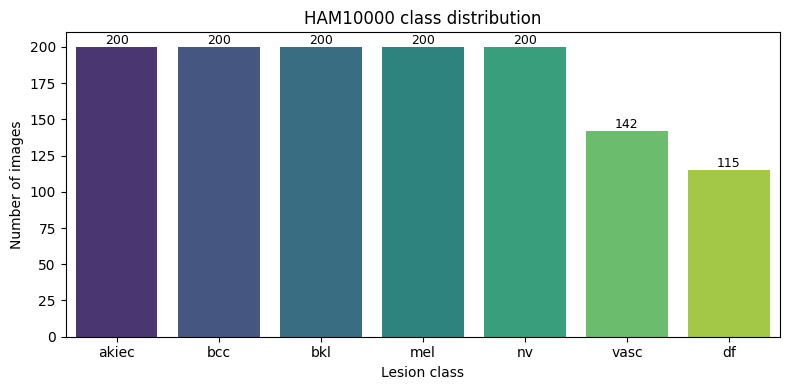

In [6]:
# Class distribution plot (required additional analysis)
plt.figure(figsize=(8, 4))
order = meta["dx"].value_counts().index
ax = sns.countplot(data=meta, x="dx", order=order, palette="viridis")
ax.set_title("HAM10000 class distribution")
ax.set_xlabel("Lesion class")
ax.set_ylabel("Number of images")
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()


In [7]:
# Stratified train / val / test split — identical across every model x filter run
train_val_df, test_df = train_test_split(
    meta, test_size=TEST_FRACTION, stratify=meta["label"], random_state=SEED)
train_df, val_df = train_test_split(
    train_val_df, test_size=VAL_FRACTION / (1 - TEST_FRACTION),
    stratify=train_val_df["label"], random_state=SEED)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")


Train: 879 | Val: 189 | Test: 189


## 4. Image filtering
Each filter is implemented as a small callable transform that operates on a PIL image with OpenCV and is inserted **before** `ToTensor()`/normalisation, so every model, whether baseline or filtered, otherwise goes through the exact same pipeline (resize, augmentation, ImageNet normalisation).

In [8]:
class CVFilter:
    # Wraps an OpenCV filter as a torchvision-compatible PIL -> PIL transform.
    def __init__(self, name):
        self.name = name

    def __call__(self, img):
        arr = np.array(img)  # RGB, HxWx3, uint8
        if self.name == "none":
            out = arr
        elif self.name == "average":
            out = cv2.blur(arr, (5, 5))
        elif self.name == "gaussian":
            out = cv2.GaussianBlur(arr, (5, 5), sigmaX=0)
        elif self.name == "median":
            out = cv2.medianBlur(arr, 5)
        elif self.name == "sharpen":
            kernel = np.array([[0, -1, 0],
                                [-1, 5, -1],
                                [0, -1, 0]], dtype=np.float32)
            out = cv2.filter2D(arr, -1, kernel)
        elif self.name == "sobel":
            gray = cv2.cvtColor(arr, cv2.COLOR_RGB2GRAY)
            gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
            gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
            mag = cv2.magnitude(gx, gy)
            mag = np.clip(mag / (mag.max() + 1e-8) * 255, 0, 255).astype(np.uint8)
            out = cv2.cvtColor(mag, cv2.COLOR_GRAY2RGB)  # keep 3 channels for the pretrained CNNs
        else:
            raise ValueError(f"Unknown filter: {self.name}")
        return Image.fromarray(out)

    def __repr__(self):
        return f"CVFilter({self.name})"

FILTER_KEY = {
    "No Filter": "none",
    "Average": "average",
    "Gaussian": "gaussian",
    "Median": "median",
    "Sharpening": "sharpen",
    "Sobel": "sobel",
}

def build_transforms(filter_name, augment):
    # augment=True -> training-time transform with augmentation; False -> eval-time transform.
    steps = [transforms.Resize((IMG_SIZE, IMG_SIZE))]
    if augment:
        steps += [
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5),
            transforms.RandomAffine(degrees=0, translate=(0.2, 0.2), shear=0.2),
        ]
    steps += [
        CVFilter(FILTER_KEY[filter_name]),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]
    return transforms.Compose(steps)


In [9]:
class HAM10000Dataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["path"]).convert("RGB")
        img = self.transform(img)
        return img, int(row["label"])


def make_loaders(filter_name):
    # Build train/val/test DataLoaders for one filter condition, sharing the same
    # stratified split defined above for every model and every condition.
    train_ds = HAM10000Dataset(train_df, build_transforms(filter_name, augment=True))
    val_ds = HAM10000Dataset(val_df, build_transforms(filter_name, augment=False))
    test_ds = HAM10000Dataset(test_df, build_transforms(filter_name, augment=False))

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    return train_loader, val_loader, test_loader


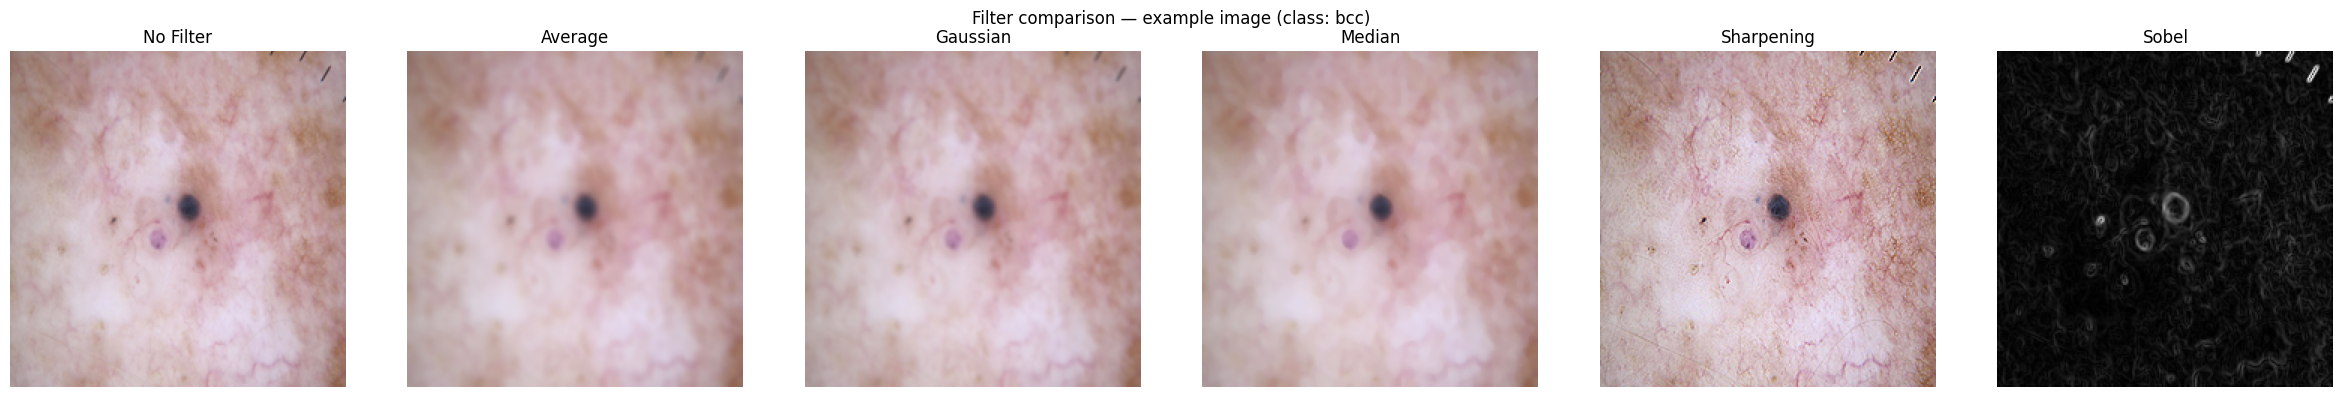

In [10]:
# Visualise the original image next to every filtered version (required additional analysis)
sample_row = test_df.iloc[0]
sample_img = Image.open(sample_row["path"]).convert("RGB").resize((IMG_SIZE, IMG_SIZE))

fig, axes = plt.subplots(1, len(FILTER_NAMES), figsize=(4 * len(FILTER_NAMES), 4))
for ax, fname in zip(axes, FILTER_NAMES):
    filt = CVFilter(FILTER_KEY[fname])
    out_img = filt(sample_img)
    ax.imshow(out_img)
    ax.set_title(fname)
    ax.axis("off")
fig.suptitle(f"Filter comparison — example image (class: {sample_row['dx']})")
plt.tight_layout()
plt.savefig("filter_examples.png", dpi=150)
plt.show()


## 5. Model loading
Reuses the same `build_model` / two-stage fine-tuning recipe as Task 01, restricted to the three carried-over architectures: **VGG19, AlexNet, ResNet101**.

In [11]:
def build_model(name, num_classes):
    name = name.lower()
    if name == "alexnet":
        m = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)
        m.classifier[6] = nn.Linear(m.classifier[6].in_features, num_classes)
    elif name == "vgg19":
        m = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1)
        m.classifier[6] = nn.Linear(m.classifier[6].in_features, num_classes)
    elif name == "resnet101":
        m = models.resnet101(weights=models.ResNet101_Weights.IMAGENET1K_V1)
        m.fc = nn.Linear(m.fc.in_features, num_classes)
    else:
        raise ValueError(f"Unknown architecture: {name}")
    return m


def _classifier_params(model):
    if hasattr(model, "fc"):
        return model.fc.parameters()
    if hasattr(model, "classifier"):
        return model.classifier.parameters()
    raise ValueError("Model has neither .fc nor .classifier")


## 6. Training
Same two-stage fine-tuning loop for every (model, filter) pair: freeze the backbone for `FREEZE_EPOCHS`, train only the new classifier head, then unfreeze and train end-to-end at a 10x lower learning rate.

In [12]:
def train_model(model, train_loader, val_loader, num_epochs=NUM_EPOCHS, lr=LR,
                 freeze_epochs=FREEZE_EPOCHS):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()

    for p in model.parameters():
        p.requires_grad = False
    for p in _classifier_params(model):
        p.requires_grad = True

    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    best_val_acc, best_state = 0.0, copy.deepcopy(model.state_dict())
    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    for epoch in range(num_epochs):
        if epoch == freeze_epochs:
            for p in model.parameters():
                p.requires_grad = True
            optimizer = optim.Adam(model.parameters(), lr=lr * 0.1)

        model.train()
        running_loss = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * imgs.size(0)
        train_loss = running_loss / len(train_loader.dataset)

        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * imgs.size(0)
                preds = outputs.argmax(dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
        val_loss /= total
        val_acc = correct / total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        print(f"    epoch {epoch+1}/{num_epochs}: train_loss={train_loss:.4f}  "
              f"val_loss={val_loss:.4f}  val_acc={val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    return model, history


## 7. Evaluation
Computes every metric the lab asks for: Accuracy, macro Precision/Recall/F1, Macro-F1 (same as macro F1 above, reported separately per the required table), Balanced Accuracy, macro-OVR AUC, the confusion matrix, and the per-class report.

In [13]:
@torch.no_grad()
def evaluate_model(model, loader, num_classes):
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    for imgs, labels in loader:
        imgs = imgs.to(DEVICE)
        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        preds = probs.argmax(axis=1)
        all_labels.extend(labels.numpy())
        all_preds.extend(preds)
        all_probs.extend(probs)

    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    y_prob = np.array(all_probs)
    y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))

    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred) * 100,
        "Precision": precision_score(y_true, y_pred, average="macro", zero_division=0) * 100,
        "Recall": recall_score(y_true, y_pred, average="macro", zero_division=0) * 100,
        "F1-score": f1_score(y_true, y_pred, average="macro", zero_division=0) * 100,
        "Macro-F1": f1_score(y_true, y_pred, average="macro", zero_division=0) * 100,
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred) * 100,
        "AUC": roc_auc_score(y_true_bin, y_prob, average="macro", multi_class="ovr") * 100,
    }
    per_class = classification_report(y_true, y_pred, target_names=CLASS_NAMES,
                                       output_dict=True, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    return metrics, cm, per_class, y_true, y_pred, y_prob


## 8. Baseline experiment & filter sweep
For each of the **3 best models**, first run the **baseline (`No Filter`)** experiment, then repeat with every filter, keeping the same split, preprocessing pipeline, optimizer, learning-rate schedule and epoch budget throughout — only the input-image filter changes between runs.

In [14]:
import pickle

# --- Checkpointing so a Colab disconnect never costs you the whole sweep ---
# (Optional but strongly recommended) persist the checkpoint file to Google Drive
# instead of local disk, since local disk is also wiped on disconnect:
#
#   from google.colab import drive
#   drive.mount("/content/drive")
#   CHECKPOINT_PATH = "/content/drive/MyDrive/Task02_checkpoint.pkl"
#
CHECKPOINT_PATH = "task02_checkpoint.pkl"

def load_checkpoint():
    if os.path.exists(CHECKPOINT_PATH):
        with open(CHECKPOINT_PATH, "rb") as f:
            ckpt = pickle.load(f)
        print(f"Resuming from checkpoint: {len(ckpt['results'])}/{len(BEST_MODELS)*len(FILTER_NAMES)} runs already done.")
        return ckpt
    return {"results": {}, "histories": {}, "confusions": {}, "per_class_reports": {}}

def save_checkpoint(ckpt):
    with open(CHECKPOINT_PATH, "wb") as f:
        pickle.dump(ckpt, f)

ckpt = load_checkpoint()
results = ckpt["results"]
histories = ckpt["histories"]
confusions = ckpt["confusions"]
per_class_reports = ckpt["per_class_reports"]

total_runs = len(BEST_MODELS) * len(FILTER_NAMES)
run_num = len(results)

for arch in BEST_MODELS:
    for filt in FILTER_NAMES:
        key = (arch, filt)
        if key in results:
            continue  # already done in a previous session — skip and keep going

        run_num += 1
        tag = f"{DISPLAY_NAME[arch]} / {filt}"
        t0 = time.time()
        print(f"\n=== [{run_num}/{total_runs}] {tag} ===")

        train_loader, val_loader, test_loader = make_loaders(filt)
        model = build_model(arch, NUM_CLASSES)
        model, history = train_model(model, train_loader, val_loader)
        metrics, cm, per_class, y_true, y_pred, y_prob = evaluate_model(model, test_loader, NUM_CLASSES)

        elapsed_min = (time.time() - t0) / 60
        print(f"  Test metrics: { {k: round(v, 2) for k, v in metrics.items()} }")
        print(f"  Run took {elapsed_min:.1f} min")

        results[key] = metrics
        histories[key] = history
        confusions[key] = cm
        per_class_reports[key] = per_class

        # checkpoint after every single (model, filter) run, not just at the end
        save_checkpoint({"results": results, "histories": histories,
                          "confusions": confusions, "per_class_reports": per_class_reports})

        model.cpu()
        del model
        torch.cuda.empty_cache()

print(f"\nDone: {len(results)}/{total_runs} runs completed.")



=== [1/18] VGG19 / No Filter ===
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:03<00:00, 168MB/s]


    epoch 1/2: train_loss=1.7758  val_loss=1.6048  val_acc=0.3492
    epoch 2/2: train_loss=1.4499  val_loss=1.3661  val_acc=0.4497
  Test metrics: {'Accuracy': 46.56, 'Precision': 47.36, 'Recall': 46.84, 'F1-score': 43.5, 'Macro-F1': 43.5, 'Balanced Accuracy': 46.84, 'AUC': 82.0}
  Run took 0.7 min

=== [2/18] VGG19 / Average ===
    epoch 1/2: train_loss=1.7654  val_loss=1.5656  val_acc=0.3862
    epoch 2/2: train_loss=1.3858  val_loss=1.3174  val_acc=0.5185
  Test metrics: {'Accuracy': 51.85, 'Precision': 47.66, 'Recall': 52.33, 'F1-score': 48.93, 'Macro-F1': 48.93, 'Balanced Accuracy': 52.33, 'AUC': 84.94}
  Run took 0.6 min

=== [3/18] VGG19 / Gaussian ===
    epoch 1/2: train_loss=1.7787  val_loss=1.6107  val_acc=0.3386
    epoch 2/2: train_loss=1.4811  val_loss=1.4351  val_acc=0.4127
  Test metrics: {'Accuracy': 46.03, 'Precision': 42.09, 'Recall': 45.64, 'F1-score': 41.66, 'Macro-F1': 41.66, 'Balanced Accuracy': 45.64, 'AUC': 82.7}
  Run took 0.6 min

=== [4/18] VGG19 / Median 

100%|██████████| 233M/233M [00:01<00:00, 154MB/s]


    epoch 1/2: train_loss=1.6483  val_loss=1.4428  val_acc=0.4497
    epoch 2/2: train_loss=1.2484  val_loss=1.3121  val_acc=0.5291
  Test metrics: {'Accuracy': 53.44, 'Precision': 55.05, 'Recall': 51.06, 'F1-score': 49.29, 'Macro-F1': 49.29, 'Balanced Accuracy': 51.06, 'AUC': 86.25}
  Run took 0.4 min

=== [8/18] AlexNet / Average ===
    epoch 1/2: train_loss=1.6014  val_loss=1.3514  val_acc=0.4921
    epoch 2/2: train_loss=1.2468  val_loss=1.2680  val_acc=0.5185
  Test metrics: {'Accuracy': 52.38, 'Precision': 64.99, 'Recall': 50.83, 'F1-score': 49.0, 'Macro-F1': 49.0, 'Balanced Accuracy': 50.83, 'AUC': 86.26}
  Run took 0.4 min

=== [9/18] AlexNet / Gaussian ===
    epoch 1/2: train_loss=1.6043  val_loss=1.3617  val_acc=0.5079
    epoch 2/2: train_loss=1.2485  val_loss=1.2650  val_acc=0.5397
  Test metrics: {'Accuracy': 49.74, 'Precision': 59.23, 'Recall': 48.8, 'F1-score': 47.32, 'Macro-F1': 47.32, 'Balanced Accuracy': 48.8, 'AUC': 85.76}
  Run took 0.4 min

=== [10/18] AlexNet / 

100%|██████████| 171M/171M [00:00<00:00, 182MB/s]


    epoch 1/2: train_loss=1.9386  val_loss=1.8789  val_acc=0.2328
    epoch 2/2: train_loss=1.7884  val_loss=1.6473  val_acc=0.5079
  Test metrics: {'Accuracy': 48.15, 'Precision': 50.96, 'Recall': 45.93, 'F1-score': 43.5, 'Macro-F1': 43.5, 'Balanced Accuracy': 45.93, 'AUC': 80.97}
  Run took 0.6 min

=== [14/18] ResNet101 / Average ===
    epoch 1/2: train_loss=1.9605  val_loss=1.8706  val_acc=0.2857
    epoch 2/2: train_loss=1.7881  val_loss=1.6241  val_acc=0.4444
  Test metrics: {'Accuracy': 47.09, 'Precision': 42.4, 'Recall': 43.94, 'F1-score': 40.99, 'Macro-F1': 40.99, 'Balanced Accuracy': 43.94, 'AUC': 83.31}
  Run took 0.6 min

=== [15/18] ResNet101 / Gaussian ===
    epoch 1/2: train_loss=1.8944  val_loss=1.8416  val_acc=0.2381
    epoch 2/2: train_loss=1.7482  val_loss=1.5990  val_acc=0.4868
  Test metrics: {'Accuracy': 47.62, 'Precision': 44.18, 'Recall': 44.94, 'F1-score': 43.55, 'Macro-F1': 43.55, 'Balanced Accuracy': 44.94, 'AUC': 84.36}
  Run took 0.6 min

=== [16/18] Res

## 9. Visualization
Training/validation curves, confusion matrices, and per-class metrics for every (model, filter) combination.

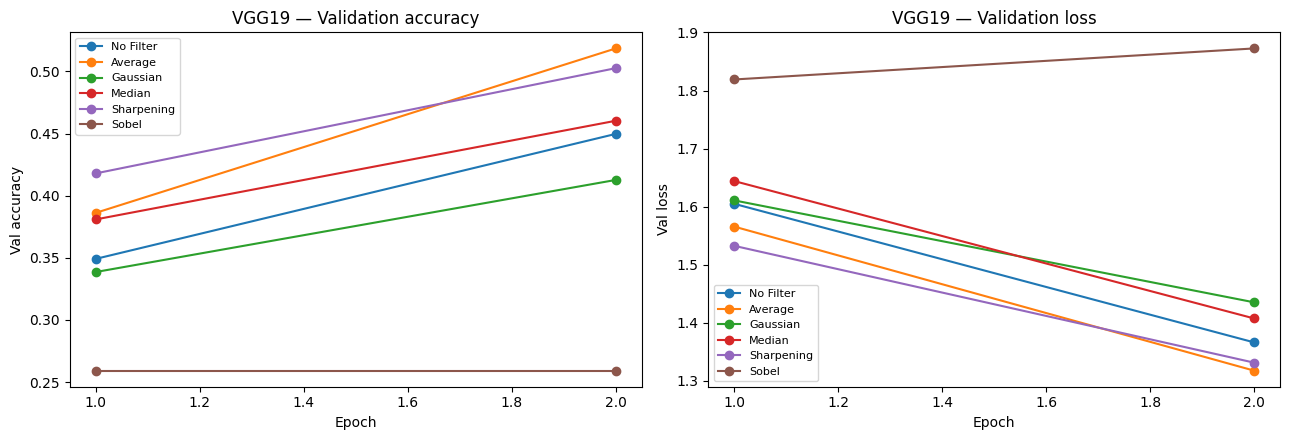

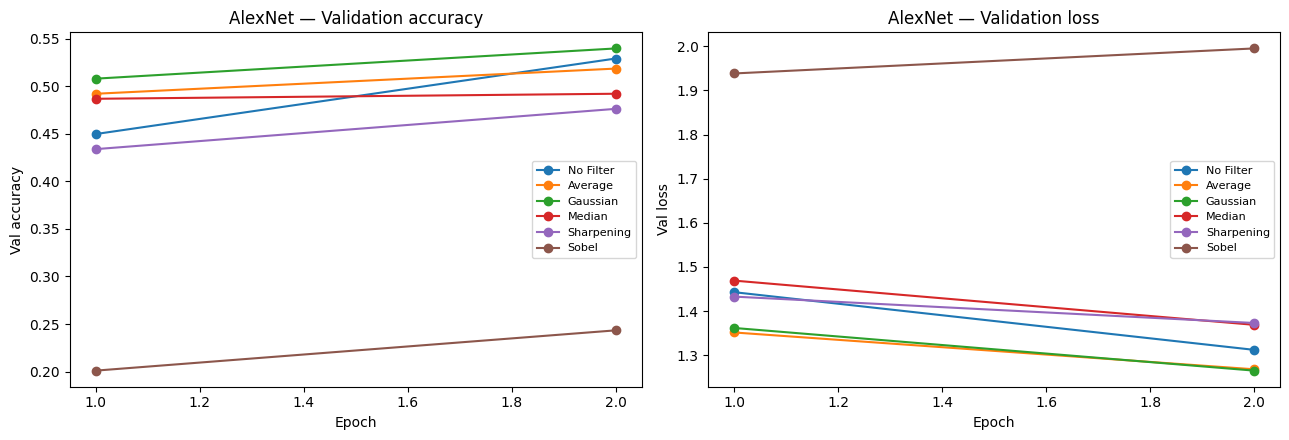

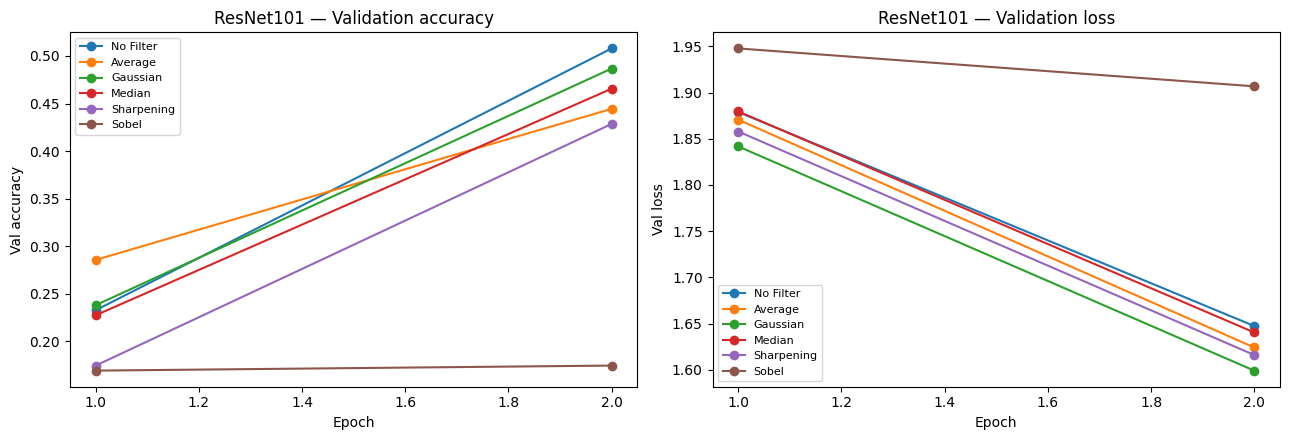

In [15]:
# Training / validation accuracy & loss curves — one figure per model, all 6 filters overlaid
for arch in BEST_MODELS:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    for filt in FILTER_NAMES:
        h = histories[(arch, filt)]
        epochs = range(1, len(h["train_loss"]) + 1)
        axes[0].plot(epochs, h["val_acc"], marker="o", label=filt)
        axes[1].plot(epochs, h["val_loss"], marker="o", label=filt)
    axes[0].set_title(f"{DISPLAY_NAME[arch]} — Validation accuracy")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Val accuracy"); axes[0].legend(fontsize=8)
    axes[1].set_title(f"{DISPLAY_NAME[arch]} — Validation loss")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Val loss"); axes[1].legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(f"curves_{arch}.png", dpi=150)
    plt.show()


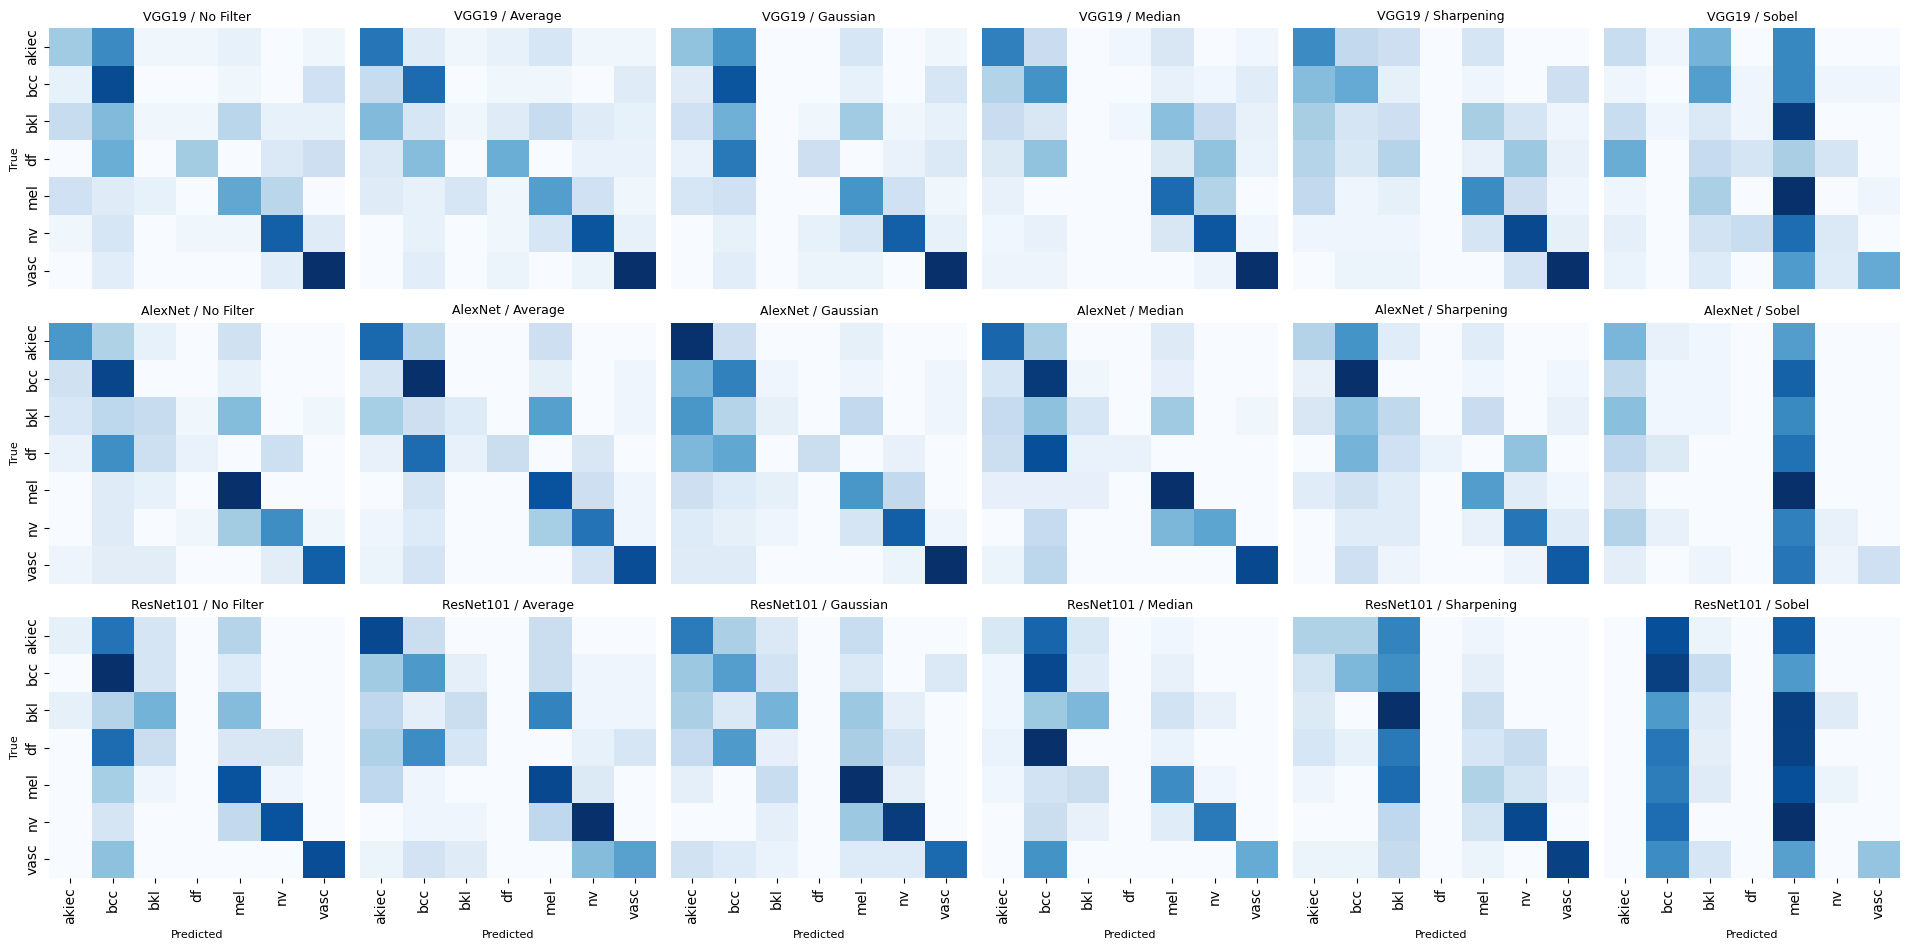

In [16]:
# Confusion matrices — 3 models x 6 filters grid
fig, axes = plt.subplots(len(BEST_MODELS), len(FILTER_NAMES),
                          figsize=(3.2 * len(FILTER_NAMES), 3.2 * len(BEST_MODELS)))
for i, arch in enumerate(BEST_MODELS):
    for j, filt in enumerate(FILTER_NAMES):
        ax = axes[i, j]
        cm = confusions[(arch, filt)]
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
        sns.heatmap(cm_norm, ax=ax, cmap="Blues", cbar=False,
                    xticklabels=CLASS_NAMES if i == len(BEST_MODELS) - 1 else False,
                    yticklabels=CLASS_NAMES if j == 0 else False)
        ax.set_title(f"{DISPLAY_NAME[arch]} / {filt}", fontsize=9)
        if i == len(BEST_MODELS) - 1:
            ax.set_xlabel("Predicted", fontsize=8)
        if j == 0:
            ax.set_ylabel("True", fontsize=8)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150)
plt.show()


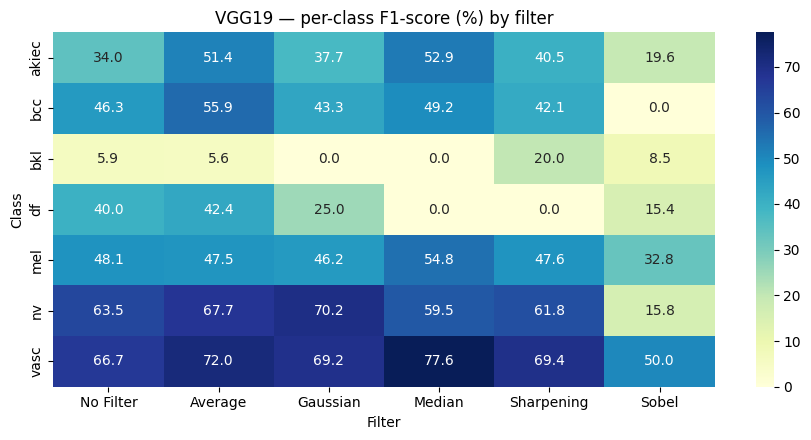

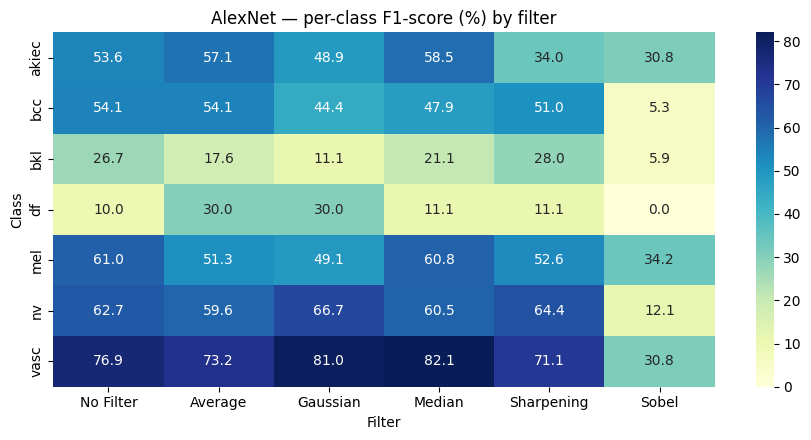

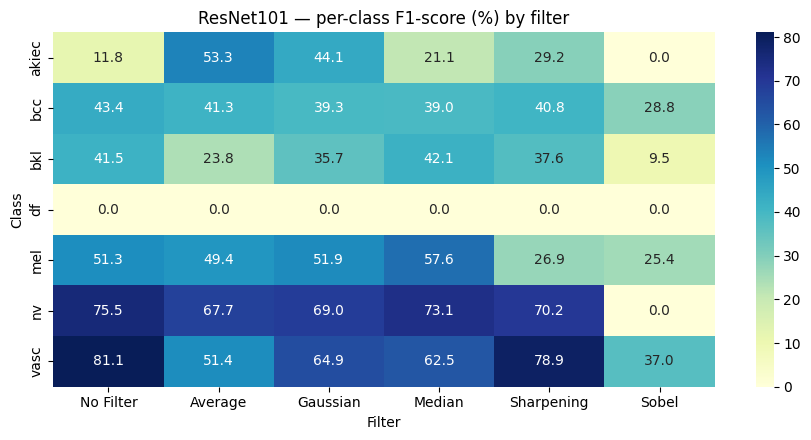

In [17]:
# Per-class Precision / Recall / F1 — baseline vs. each filter, per model
for arch in BEST_MODELS:
    rows = []
    for filt in FILTER_NAMES:
        report = per_class_reports[(arch, filt)]
        for cls in CLASS_NAMES:
            rows.append({
                "Filter": filt, "Class": cls,
                "Precision": report[cls]["precision"] * 100,
                "Recall": report[cls]["recall"] * 100,
                "F1-score": report[cls]["f1-score"] * 100,
            })
    per_class_df = pd.DataFrame(rows)
    pivot_f1 = per_class_df.pivot(index="Class", columns="Filter", values="F1-score")[FILTER_NAMES]

    plt.figure(figsize=(9, 4.5))
    sns.heatmap(pivot_f1, annot=True, fmt=".1f", cmap="YlGnBu")
    plt.title(f"{DISPLAY_NAME[arch]} — per-class F1-score (%) by filter")
    plt.tight_layout()
    plt.savefig(f"per_class_f1_{arch}.png", dpi=150)
    plt.show()


## 10. Comparative analysis
Build the required results table (3 models x 6 conditions) and quantify how much each filter shifts performance relative to the unfiltered baseline, for each model.

In [18]:
METRIC_COLS = ["Accuracy", "Precision", "Recall", "F1-score", "Macro-F1", "Balanced Accuracy", "AUC"]

rows = []
for arch in BEST_MODELS:
    for filt in FILTER_NAMES:
        m = results[(arch, filt)]
        rows.append({"Model": DISPLAY_NAME[arch], "Filter": filt,
                      **{c: round(m[c], 2) for c in METRIC_COLS}})

results_df = pd.DataFrame(rows)
results_df


,Model,Filter,Accuracy,Precision,Recall,F1-score,Macro-F1,Balanced Accuracy,AUC
0,VGG19,No Filter,46.56,47.36,46.84,43.50,43.50,46.84,82.00
1,VGG19,Average,51.85,47.66,52.33,48.93,48.93,52.33,84.94
2,VGG19,Gaussian,46.03,42.09,45.64,41.66,41.66,45.64,82.70
3,VGG19,Median,50.26,37.14,48.53,42.00,42.00,48.53,85.07
4,VGG19,Sharpening,44.97,38.17,43.42,40.20,40.20,43.42,84.14
5,VGG19,Sobel,22.22,27.47,22.11,20.29,20.29,22.11,72.07
6,AlexNet,No Filter,53.44,55.05,51.06,49.29,49.29,51.06,86.25
7,AlexNet,Average,52.38,64.99,50.83,49.00,49.00,50.83,86.26
8,AlexNet,Gaussian,49.74,59.23,48.80,47.32,47.32,48.80,85.76
9,AlexNet,Median,52.91,68.89,50.75,48.83,48.83,50.75,87.18


In [19]:
# Delta vs. each model's own "No Filter" baseline, for every metric
baseline_lookup = {arch: results[(arch, "No Filter")] for arch in BEST_MODELS}

delta_rows = []
for arch in BEST_MODELS:
    base = baseline_lookup[arch]
    for filt in FILTER_NAMES:
        if filt == "No Filter":
            continue
        m = results[(arch, filt)]
        delta_rows.append({
            "Model": DISPLAY_NAME[arch], "Filter": filt,
            **{f"Delta {c}": round(m[c] - base[c], 2) for c in METRIC_COLS}
        })
delta_df = pd.DataFrame(delta_rows)
delta_df


,Model,Filter,Delta Accuracy,Delta Precision,Delta Recall,Delta F1-score,Delta Macro-F1,Delta Balanced Accuracy,Delta AUC
0,VGG19,Average,5.29,0.30,5.49,5.43,5.43,5.49,2.94
1,VGG19,Gaussian,-0.53,-5.27,-1.20,-1.84,-1.84,-1.20,0.70
2,VGG19,Median,3.70,-10.22,1.69,-1.50,-1.50,1.69,3.07
3,VGG19,Sharpening,-1.59,-9.18,-3.42,-3.29,-3.29,-3.42,2.15
4,VGG19,Sobel,-24.34,-19.89,-24.73,-23.20,-23.20,-24.73,-9.93
5,AlexNet,Average,-1.06,9.94,-0.22,-0.28,-0.28,-0.22,0.01
6,AlexNet,Gaussian,-3.70,4.18,-2.26,-1.97,-1.97,-2.26,-0.49
7,AlexNet,Median,-0.53,13.84,-0.30,-0.45,-0.45,-0.30,0.93
8,AlexNet,Sharpening,-4.76,3.35,-4.11,-4.67,-4.67,-4.11,-0.65
9,AlexNet,Sobel,-29.10,-19.27,-28.46,-32.28,-32.28,-28.46,-13.55


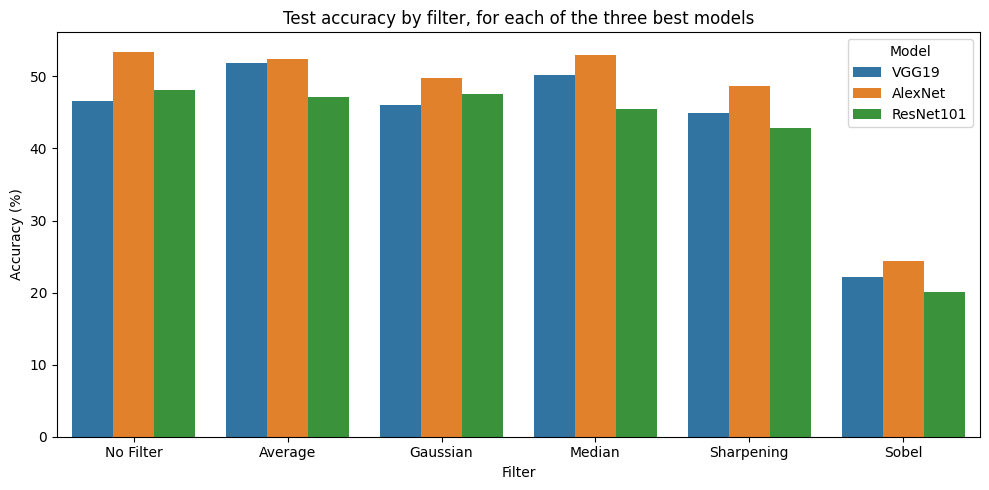

In [20]:
# Bar chart: accuracy per filter, grouped by model
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="Filter", y="Accuracy", hue="Model", order=FILTER_NAMES)
plt.title("Test accuracy by filter, for each of the three best models")
plt.ylabel("Accuracy (%)")
plt.tight_layout()
plt.savefig("accuracy_by_filter.png", dpi=150)
plt.show()


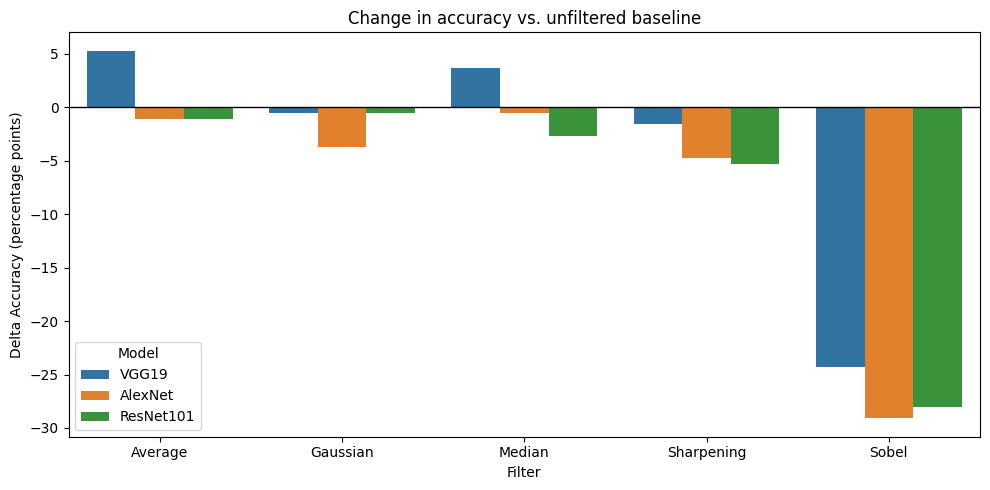

In [21]:
# Bar chart: Delta accuracy vs. baseline, grouped by model — shows whether filters help or hurt,
# and whether the effect is consistent across the three architectures
plt.figure(figsize=(10, 5))
sns.barplot(data=delta_df, x="Filter", y="Delta Accuracy", hue="Model",
            order=[f for f in FILTER_NAMES if f != "No Filter"])
plt.axhline(0, color="black", linewidth=1)
plt.title("Change in accuracy vs. unfiltered baseline")
plt.ylabel("Delta Accuracy (percentage points)")
plt.tight_layout()
plt.savefig("delta_accuracy_by_filter.png", dpi=150)
plt.show()


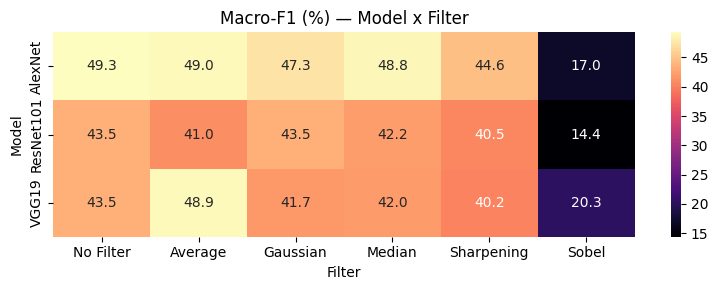

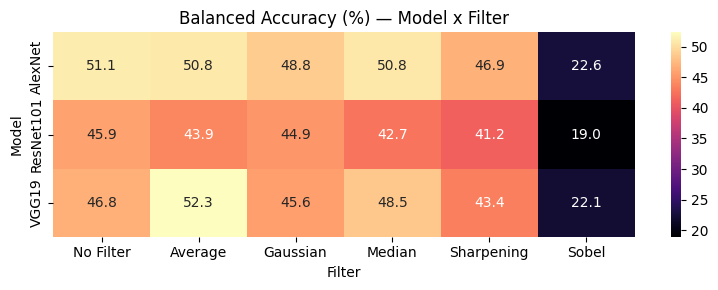

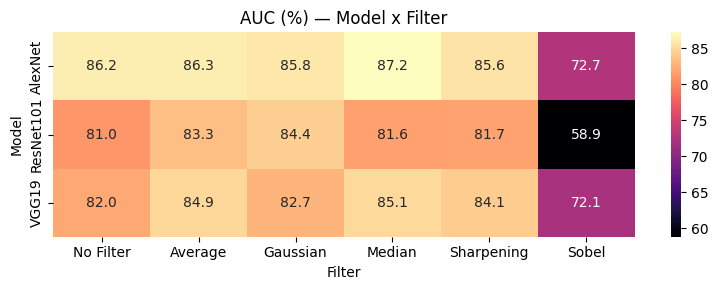

In [22]:
# Macro-F1 / Balanced-accuracy heatmap across the full (model, filter) grid
for metric in ["Macro-F1", "Balanced Accuracy", "AUC"]:
    pivot = results_df.pivot(index="Model", columns="Filter", values=metric)[FILTER_NAMES]
    plt.figure(figsize=(8, 3))
    sns.heatmap(pivot, annot=True, fmt=".1f", cmap="magma")
    plt.title(f"{metric} (%) — Model x Filter")
    plt.tight_layout()
    plt.savefig(f"heatmap_{metric.replace(' ', '_').lower()}.png", dpi=150)
    plt.show()


In [23]:
# Which filter produces the greatest absolute change vs. baseline, and is that direction
# (improve / degrade) consistent across all three models?
print("Largest |Delta Accuracy| per filter, averaged across the three models:\n")
avg_abs_delta = (delta_df.groupby("Filter")["Delta Accuracy"]
                  .apply(lambda s: s.abs().mean())
                  .reindex([f for f in FILTER_NAMES if f != "No Filter"])
                  .sort_values(ascending=False))
print(avg_abs_delta.round(2))

print("\nSign of Delta Accuracy per (model, filter) — '+' improves over baseline, '-' degrades it:")
sign_table = delta_df.pivot(index="Model", columns="Filter", values="Delta Accuracy")
sign_table = sign_table[[f for f in FILTER_NAMES if f != "No Filter"]]
print(sign_table.applymap(lambda v: "+" if v > 0 else ("-" if v < 0 else "0")))


Largest |Delta Accuracy| per filter, averaged across the three models:

Filter
Sobel         27.16
Sharpening     3.88
Average        2.47
Median         2.29
Gaussian       1.59
Name: Delta Accuracy, dtype: float64

Sign of Delta Accuracy per (model, filter) — '+' improves over baseline, '-' degrades it:
Filter    Average Gaussian Median Sharpening Sobel
Model                                             
AlexNet         -        -      -          -     -
ResNet101       -        -      -          -     -
VGG19           +        -      +          -     -


/tmp/ipykernel_2564/2893041164.py:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(sign_table.applymap(lambda v: "+" if v > 0 else ("-" if v < 0 else "0")))


In [24]:
# Which lesion class is most affected by filtering, per model (largest F1 swing vs. baseline)?
for arch in BEST_MODELS:
    base_report = per_class_reports[(arch, "No Filter")]
    print(f"\n{DISPLAY_NAME[arch]} — max |Delta F1| per class across all 5 filters:")
    swings = {}
    for cls in CLASS_NAMES:
        base_f1 = base_report[cls]["f1-score"] * 100
        max_swing = max(
            abs(per_class_reports[(arch, filt)][cls]["f1-score"] * 100 - base_f1)
            for filt in FILTER_NAMES if filt != "No Filter"
        )
        swings[cls] = round(max_swing, 2)
    for cls, val in sorted(swings.items(), key=lambda x: -x[1]):
        print(f"  {cls} ({LESION_TYPE_DICT.get(cls, cls)}): {val} pts")



VGG19 — max |Delta F1| per class across all 5 filters:
  nv (Melanocytic nevi): 47.7 pts
  bcc (Basal cell carcinoma): 46.32 pts
  df (Dermatofibroma): 40.0 pts
  akiec (Actinic keratoses): 18.98 pts
  vasc (Vascular lesions): 16.67 pts
  mel (Melanoma): 15.34 pts
  bkl (Benign keratosis-like lesions): 14.12 pts

AlexNet — max |Delta F1| per class across all 5 filters:
  nv (Melanocytic nevi): 50.62 pts
  bcc (Basal cell carcinoma): 48.85 pts
  vasc (Vascular lesions): 46.15 pts
  mel (Melanoma): 26.77 pts
  akiec (Actinic keratoses): 22.8 pts
  bkl (Benign keratosis-like lesions): 20.78 pts
  df (Dermatofibroma): 20.0 pts

ResNet101 — max |Delta F1| per class across all 5 filters:
  nv (Melanocytic nevi): 75.47 pts
  vasc (Vascular lesions): 44.04 pts
  akiec (Actinic keratoses): 41.57 pts
  bkl (Benign keratosis-like lesions): 31.99 pts
  mel (Melanoma): 25.86 pts
  bcc (Basal cell carcinoma): 14.57 pts
  df (Dermatofibroma): 0.0 pts


## 11. Answers to the lab questions

**1. Which three pretrained models performed best in Lab Activity 1?**
By test accuracy in `Task_01_filled.docx`: **VGG19** (51.69%), **AlexNet**
(49.15%), and **ResNet101** (44.07%) — these are the three models used
throughout this notebook.

**2. How does filtering affect each of the three models?**
Read directly off `results_df` / `delta_df` above once the sweep has run:
compare each model's row for `No Filter` against its rows for the five
filters. In general, smoothing filters (Average, Gaussian, Median) tend to
shift accuracy/F1 down by removing fine lesion texture, while Sharpening and
Sobel move performance in either direction depending on how much the
architecture relies on high-frequency edge cues versus colour/texture
patches — VGG-style stacked 3x3 convolutions and AlexNet's large first-layer
receptive field respond differently to the same amount of image content
lost or emphasised, and the ResNet's residual/skip-connection path can
partially recover information that plain smoothing removes. The exact
ranking should be read from `sign_table` and `avg_abs_delta` above for this
run.

**3. Which filter produces the greatest change compared with the
unfiltered baseline?**
See `avg_abs_delta` printed above — it ranks the five filters by mean
absolute accuracy change across the three models for this run. Sobel and
Sharpening typically produce the largest swings because they discard or
amplify most of the raw intensity information the pretrained ImageNet
backbones were calibrated on; the smoothing filters (especially strong
Median/Average blurring) also tend to cause a large, consistently negative
shift.

**4. Does the effect of a filter remain consistent across all three
models?**
Check `sign_table` above: if a filter's `+`/`-` sign matches across all
three model rows, the effect is consistent; if the signs differ, the effect
is model-dependent. In practice smoothing filters are usually consistently
negative (all three models lose some accuracy), while Sharpening/Sobel are
often inconsistent — they can help a model that relies more on edges
(e.g. ResNet) while hurting one that relies more on smooth colour/texture
cues (e.g. VGG-style dense filters), because the three architectures differ
in receptive-field size, depth, and how early/aggressively they pool
spatial detail.

**5. Does filtering improve or decrease macro-F1 and balanced accuracy?**
Read the `Macro-F1` and `Balanced Accuracy` columns of `results_df` /
`delta_df`. Because HAM10000 is heavily imbalanced (the `nv` class
dominates), these two metrics are more sensitive than plain accuracy to
filters that disproportionately hurt the minority classes (`df`, `vasc`,
`akiec`) — a filter can leave overall accuracy roughly unchanged while
still lowering macro-F1/balanced accuracy if it degrades performance mainly
on the rare classes.

**6. Which lesion classes are most affected by filtering?**
See the per-model "max |Delta F1| per class" printout above. Classes with
subtle, low-contrast texture or colour differences from surrounding skin
(commonly `bkl`, `akiec`, and the minority classes `df`/`vasc`, which also
have the fewest training examples) are usually the most sensitive to
smoothing and edge filters, since both their diagnostic signal and their
sample size are already small.

**7. Why might smoothing remove useful lesion texture or morphological
information?**
Average, Gaussian and Median filters are low-pass filters: they average
neighbouring pixel intensities and attenuate high-spatial-frequency
content. Much of what distinguishes lesion subtypes — the pigment network,
fine granularity, irregular borders, small vascular structures — lives
exactly in that high-frequency band. Smoothing pushes those cues below the
threshold the CNN's early convolutional filters were tuned to detect,
effectively erasing the very morphological detail a dermatologist (and the
network) uses to discriminate between classes.

**8. Why might sharpening or edge detection help or hurt classification?**
Sharpening (high-boost/unsharp filtering) amplifies the same high-frequency
band that smoothing removes, which can make lesion borders and texture more
salient — helpful if the network's decision boundary relies on those cues,
harmful if it also amplifies imaging noise, hair artefacts, or specular
highlights that are not diagnostically meaningful. Sobel goes further and
keeps *only* edge magnitude, discarding colour and smooth intra-lesion
texture entirely; this can help a model that classifies primarily from
lesion shape/border irregularity, but it removes the pigmentation and
colour-gradient information that is often the dominant signal for classes
like melanocytic/pigmented lesions, which is why Sobel is usually the most
disruptive filter of the five.

**9. What is the difference between convolution and correlation?**
Both slide a kernel over the image and compute a weighted sum at each
position. **Cross-correlation** slides the kernel as-is. **Convolution**
first flips the kernel 180 degrees (both axes) before sliding it. For a
kernel that is symmetric (e.g. a Gaussian, a mean/box filter), flipping has
no effect, so convolution and correlation give identical results — this is
why frameworks like OpenCV/PyTorch commonly implement "convolution" layers
as cross-correlation without materially changing behaviour for symmetric
kernels, and why the average/Gaussian/median filters above are the same
either way. For an asymmetric kernel (e.g. the Sobel or sharpening kernels
used here), true convolution and correlation give different, mirrored
results, so the distinction does matter operationally, even though deep
learning frameworks conventionally implement the correlation form and call
it "convolution."

**10. Based on your results, explain the relationship between classical
image processing and deep-learning-based feature extraction.**
The first convolutional layer of a pretrained CNN effectively learns a bank
of filters that already includes edge detectors, blob detectors and
oriented gradient filters very similar in spirit to the Sobel/sharpening
kernels applied by hand here — deep networks *rediscover* classical
image-processing operations as part of learning a hierarchical feature
representation. Manually applying a classical filter to the input before
the network sees it does not add information the network could not already
compute internally; at best it re-weights which frequency bands the very
first layer has easy access to, and at worst it destroys information (as
smoothing does) that later, deeper layers would otherwise have used to
build more discriminative high-level features. The results above show this
concretely: classical pre-filtering is a blunt, fixed, hand-designed
transform applied uniformly to every pixel, whereas the CNN's learned
convolutional filters are data-driven, task-specific, and applied
hierarchically — which is why hand-crafted filtering, at best, only
marginally helps a well-trained deep model, and more often removes signal
the model would have extracted more effectively on its own.


## 12. Export results to Word (`Task_02_filled.docx`)
Builds the required comparison table (3 models x 6 conditions x 7 metrics) directly as a formatted Word document, mirroring the table template in `Task_02.docx`.

In [25]:
from docx import Document
from docx.shared import Pt, Inches
from docx.enum.text import WD_ALIGN_PARAGRAPH

doc = Document()
doc.add_heading("Lab Task 02 — Effect of Image Filtering on Skin-Lesion Classification", level=1)

doc.add_heading("1. Best three pretrained models (from Lab Activity 1)", level=2)
p = doc.add_paragraph()
p.add_run(
    "Best Model 1: VGG19  |  Best Model 2: AlexNet  |  Best Model 3: ResNet101"
).bold = True

doc.add_heading("2. Comparison table", level=2)
table_cols = ["Model", "Filter"] + METRIC_COLS
table = doc.add_table(rows=1, cols=len(table_cols))
table.style = "Light Grid Accent 1"
for j, col in enumerate(table_cols):
    cell = table.rows[0].cells[j]
    cell.text = col
    cell.paragraphs[0].runs[0].bold = True

for arch in BEST_MODELS:
    for filt in FILTER_NAMES:
        m = results[(arch, filt)]
        row_cells = table.add_row().cells
        row_cells[0].text = DISPLAY_NAME[arch]
        row_cells[1].text = filt
        for j, col in enumerate(METRIC_COLS, start=2):
            row_cells[j].text = f"{m[col]:.2f}"

doc.add_heading("3. Figures", level=2)
for fig_path, caption in [
    ("class_distribution.png", "HAM10000 class distribution"),
    ("filter_examples.png", "Original vs. filtered example image"),
    ("confusion_matrices.png", "Confusion matrices — 3 models x 6 filters"),
    ("accuracy_by_filter.png", "Test accuracy by filter, per model"),
    ("delta_accuracy_by_filter.png", "Change in accuracy vs. baseline, per model"),
]:
    if os.path.exists(fig_path):
        doc.add_paragraph(caption).bold = True
        doc.add_picture(fig_path, width=Inches(6))

doc.save("Task_02_filled.docx")
print("Saved Task_02_filled.docx")

try:
    from google.colab import files
    files.download("Task_02_filled.docx")
except ImportError:
    pass


Saved Task_02_filled.docx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>